In [252]:
from binance.client import Client
import mplfinance as mpf
import seaborn as sns
import pandas as pd
import numpy as np
import ta

In [253]:
def get_sharpe_annualization_factor(interval_minutes):
    minutes_per_year = 365 * 24 * 60
    periods_per_year = minutes_per_year / interval_minutes
    return np.sqrt(periods_per_year)

In [254]:
ticker = "BTCUSDT"

hist_data = 7 * 4 * 6 # Six month 

interval = 60 # In minutes

forecast_horizon = 1 

annualize_rate = get_sharpe_annualization_factor(interval) # Sharpe annualize rate 

In [255]:
client = Client("", "")
dict_data = client.get_historical_klines("BTCUSDT", Client.KLINE_INTERVAL_1HOUR, "1 Jan, 2024")

df = pd.DataFrame(dict_data)

df = df.iloc[:, :6]

df.columns = ['Time', 'Open', 'High', 'Low', 'Close', 'Volume']

df['Time'] = pd.to_datetime(df['Time'], unit='ms')

df.set_index('Time', inplace=True)

df = df.apply(pd.to_numeric)

df

,Open,High,Low,Close,Volume
Time,,,,,
2024-01-01 00:00:00,42283.58,42554.57,42261.02,42475.23,1271.68108
2024-01-01 01:00:00,42475.23,42775.00,42431.65,42613.56,1196.37856
2024-01-01 02:00:00,42613.57,42638.41,42500.00,42581.10,685.21980
2024-01-01 03:00:00,42581.09,42586.64,42230.08,42330.49,794.80391
2024-01-01 04:00:00,42330.50,42399.99,42209.46,42399.99,715.41760
...,...,...,...,...,...
2026-03-09 06:00:00,67911.15,67939.55,67236.78,67267.18,578.70307
2026-03-09 07:00:00,67267.18,67575.81,66853.48,67555.13,1253.45589
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129


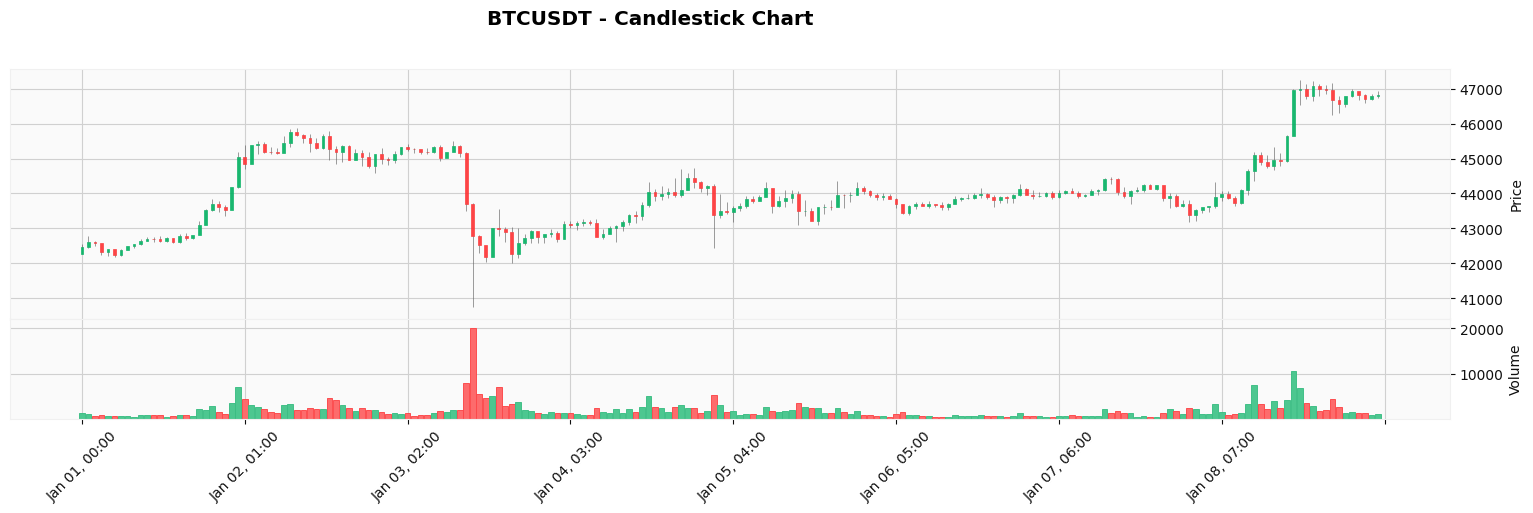

In [ ]:
mpf.plot(
    df.head(200),
    type="candle",
    style="yahoo",
    figsize=(20, 5),
    volume=True,
    title=f"{ticker} - Candlestick Chart"
)

### Feature Engineer

In [257]:
def feature_enginering(df : pd.DataFrame) -> pd.DataFrame :
    df["price_change"] = df['Close'].pct_change()
    df["high_low_ratio"] = df['High']/df['Low']
    df["open_close_ratio"] = df['Close']/df['Open']
    df["body_size"] = abs(df['Close'] - df['Open'])

    # Technical indicators (TA-Lib)
    df['rsi'] = ta.momentum.StochRSIIndicator(df['Close'], window=14).stochrsi()
    df['macd'] = ta.trend.MACD(df['Close']).macd()
    df['macd_signal'] = ta.trend.MACD(df['Close']).macd_signal()
    df['bb_upper'] = ta.volatility.BollingerBands(df['Close']).bollinger_hband()
    df['bb_lower'] = ta.volatility.BollingerBands(df['Close']).bollinger_lband()
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['Close']

    # Volume features
    df['volume_sma'] = df['Volume'].rolling(20).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_sma']
    
    # Lag indicators usefull for small timeframes to have a better overview
    for lag in [1, 3, 6, 12]:  # 5m, 15m, 30m, 1h lags
        df[f'price_lag_{lag}'] = df['Close'].pct_change(lag)
        df[f'rsi_lag_{lag}'] = df['rsi'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Volume'].shift(lag)
    
    # Volatility
    df['volatility'] = df['price_change'].rolling(20).std()
    df['atr'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()
    df['vix_proxy'] = df['Close'].pct_change().rolling(20).std() * np.sqrt(252)

    return df

In [258]:
# Creation of target and lagged values
df["close_log_return"] = np.log(df["Close"]/df["Close"].shift(forecast_horizon))
df


,Open,High,Low,Close,Volume,close_log_return
Time,,,,,,
2024-01-01 00:00:00,42283.58,42554.57,42261.02,42475.23,1271.68108,NaN
2024-01-01 01:00:00,42475.23,42775.00,42431.65,42613.56,1196.37856,0.003251
2024-01-01 02:00:00,42613.57,42638.41,42500.00,42581.10,685.21980,-0.000762
2024-01-01 03:00:00,42581.09,42586.64,42230.08,42330.49,794.80391,-0.005903
2024-01-01 04:00:00,42330.50,42399.99,42209.46,42399.99,715.41760,0.001640
...,...,...,...,...,...,...
2026-03-09 06:00:00,67911.15,67939.55,67236.78,67267.18,578.70307,-0.009528
2026-03-09 07:00:00,67267.18,67575.81,66853.48,67555.13,1253.45589,0.004272
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129,0.003835


In [259]:
target = "close_log_return"
lr = df[target]
lags = [1,2,3,4]

for lag in lags:
    df[f"{target}_lag_{lag}"] = lr.shift(forecast_horizon * lag)

df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
Time,,,,,,,,,,
2024-01-01 00:00:00,42283.58,42554.57,42261.02,42475.23,1271.68108,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00,42475.23,42775.00,42431.65,42613.56,1196.37856,0.003251,NaN,NaN,NaN,NaN
2024-01-01 02:00:00,42613.57,42638.41,42500.00,42581.10,685.21980,-0.000762,0.003251,NaN,NaN,NaN
2024-01-01 03:00:00,42581.09,42586.64,42230.08,42330.49,794.80391,-0.005903,-0.000762,0.003251,NaN,NaN
2024-01-01 04:00:00,42330.50,42399.99,42209.46,42399.99,715.41760,0.001640,-0.005903,-0.000762,0.003251,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-03-09 06:00:00,67911.15,67939.55,67236.78,67267.18,578.70307,-0.009528,0.011567,-0.001115,0.009985,0.005143
2026-03-09 07:00:00,67267.18,67575.81,66853.48,67555.13,1253.45589,0.004272,-0.009528,0.011567,-0.001115,0.009985
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129,0.003835,0.004272,-0.009528,0.011567,-0.001115


In [260]:
df = df.dropna()
df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
Time,,,,,,,,,,
2024-01-01 05:00:00,42399.98,42406.00,42180.77,42234.01,736.53152,-0.003922,0.001640,-0.005903,-0.000762,0.003251
2024-01-01 06:00:00,42234.01,42424.82,42208.68,42396.69,601.37250,0.003844,-0.003922,0.001640,-0.005903,-0.000762
2024-01-01 07:00:00,42396.69,42500.00,42396.68,42492.46,653.67718,0.002256,0.003844,-0.003922,0.001640,-0.005903
2024-01-01 08:00:00,42492.46,42556.50,42452.58,42549.99,427.19365,0.001353,0.002256,0.003844,-0.003922,0.001640
2024-01-01 09:00:00,42550.00,42699.32,42537.18,42649.69,879.62491,0.002340,0.001353,0.002256,0.003844,-0.003922
...,...,...,...,...,...,...,...,...,...,...
2026-03-09 06:00:00,67911.15,67939.55,67236.78,67267.18,578.70307,-0.009528,0.011567,-0.001115,0.009985,0.005143
2026-03-09 07:00:00,67267.18,67575.81,66853.48,67555.13,1253.45589,0.004272,-0.009528,0.011567,-0.001115,0.009985
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129,0.003835,0.004272,-0.009528,0.011567,-0.001115


<Axes: xlabel='close_log_return', ylabel='Count'>

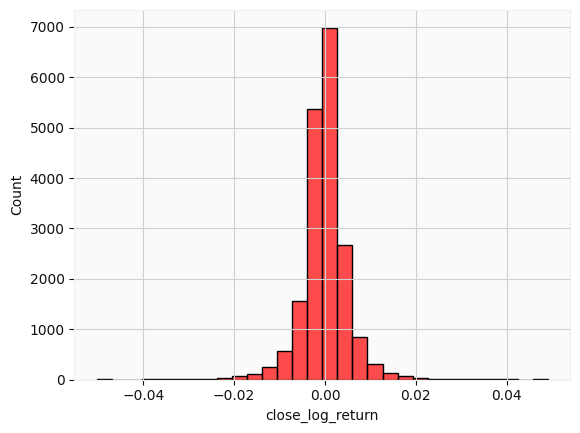

In [261]:
sns.histplot(lr, bins=30, color="red", edgecolor="black", alpha=0.7)

In [263]:
df = feature_enginering(df).dropna()
df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4,...,volume_lag_3,price_lag_6,rsi_lag_6,volume_lag_6,price_lag_12,rsi_lag_12,volume_lag_12,volatility,atr,vix_proxy
Time,,,,,,,,,,,,,,,,,,,,,
2024-01-02 19:00:00,45154.70,45243.00,44790.96,45039.49,2347.28624,-0.002554,0.004184,-0.008673,0.003822,-0.001634,...,3052.23783,-0.013113,0.184672,2253.76868,-0.009153,0.213294,3112.52478,0.006905,404.834053,0.109606
2024-01-02 20:00:00,45039.49,45180.55,44742.96,44788.28,1940.02489,-0.005593,-0.002554,0.004184,-0.008673,0.003822,...,2540.00308,-0.010395,0.000000,4553.21243,-0.021220,0.390630,3323.21707,0.005435,407.173763,0.086273
2024-01-02 21:00:00,44788.27,45119.76,44600.00,45119.74,2043.74183,0.007373,-0.005593,-0.002554,0.004184,-0.008673,...,1806.07730,-0.001440,0.000000,4301.03657,-0.012124,0.145380,2096.46195,0.005601,415.215637,0.088906
2024-01-02 22:00:00,45119.74,45297.26,44840.01,44981.73,1591.57491,-0.003063,0.007373,-0.005593,-0.002554,0.004184,...,2347.28624,-0.008292,0.099431,3052.23783,-0.013234,0.000000,2069.22249,0.004961,418.218092,0.078752
2024-01-02 23:00:00,44981.72,45049.98,44802.01,44946.91,1080.22719,-0.000774,-0.003063,0.007373,-0.005593,-0.002554,...,1940.02489,-0.000428,0.000000,2540.00308,-0.010721,0.000000,2538.49307,0.004956,406.057514,0.078680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09 06:00:00,67911.15,67939.55,67236.78,67267.18,578.70307,-0.009528,0.011567,-0.001115,0.009985,0.005143,...,1256.29482,0.013518,0.423993,951.35538,0.006933,0.023914,487.97779,0.006158,639.000546,0.097755
2026-03-09 07:00:00,67267.18,67575.81,66853.48,67555.13,1253.45589,0.004272,-0.009528,0.011567,-0.001115,0.009985,...,848.47762,0.020532,0.315670,2263.78882,0.003233,0.609516,711.10669,0.006113,644.952650,0.097043
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129,0.003835,0.004272,-0.009528,0.011567,-0.001115,...,1145.71148,0.019198,0.650229,752.57114,0.008565,0.519828,1144.93227,0.006130,637.263175,0.097314
